In [1]:
import csv
import h5py
import json

import matplotlib.pyplot as plt
import numpy as np

In [2]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [3]:
data_filename = 'bond_order_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [4]:
print_tree(data['simulation'], max_level=4)

highest
- 0.01
- - coupling_point_2
- - - (1, 2)
- - - (2, 3)
- - - (3, 4)
- - - (4, 5)
- - - (5, 6)
- - - (6, 7)
- - - (7, 8)
- - - bond_order_total
- - - bond_order_total_BS
- 0.1
- - coupling_point_2
- - - (1, 2)
- - - (2, 3)
- - - (3, 4)
- - - (4, 5)
- - - (5, 6)
- - - (6, 7)
- - - (7, 8)
- - - bond_order_total
- - - bond_order_total_BS
- 0.2
- - coupling_point_2
- - - (1, 2)
- - - (2, 3)
- - - (3, 4)
- - - (4, 5)
- - - (5, 6)
- - - (6, 7)
- - - (7, 8)
- - - bond_order_total
- - - bond_order_total_BS
- 0.3
- - coupling_point_2
- - - (1, 2)
- - - (2, 3)
- - - (3, 4)
- - - (4, 5)
- - - (5, 6)
- - - (6, 7)
- - - (7, 8)
- - - bond_order_total
- - - bond_order_total_BS
- 0.5
- - coupling_point_2
- - - (1, 2)
- - - (2, 3)
- - - (3, 4)
- - - (4, 5)
- - - (5, 6)
- - - (6, 7)
- - - (7, 8)
- - - bond_order_total
- - - bond_order_total_BS
- 0.8
- - coupling_point_2
- - - (1, 2)
- - - (2, 3)
- - - (3, 4)
- - - (4, 5)
- - - (5, 6)
- - - (6, 7)
- - - (7, 8)
- - - bond_order_total
- - - bond_orde

In [5]:
eigenstate = 'highest_postselection'
eigenstate_base = eigenstate.split('_')[0]

[(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]


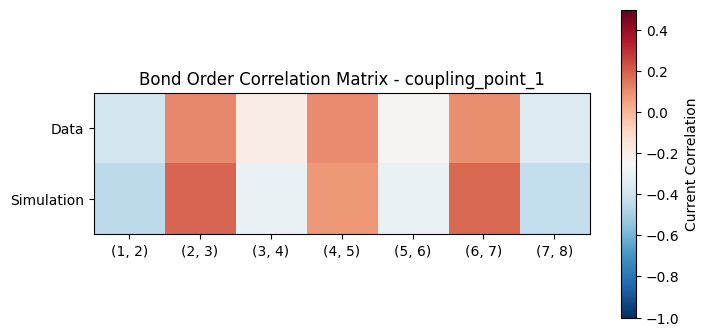

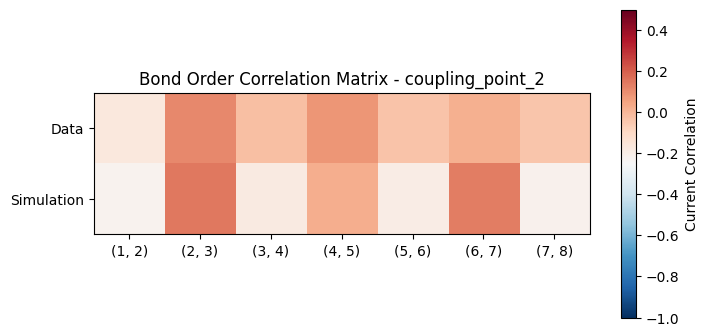

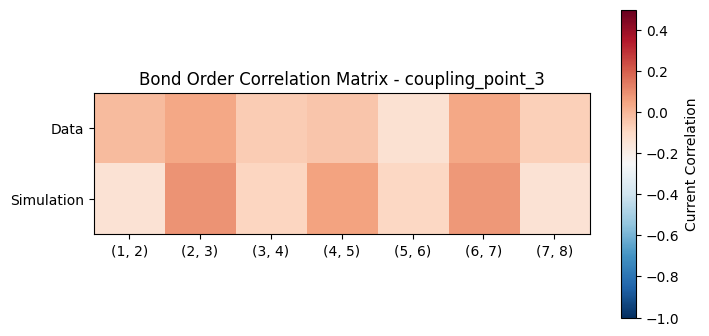

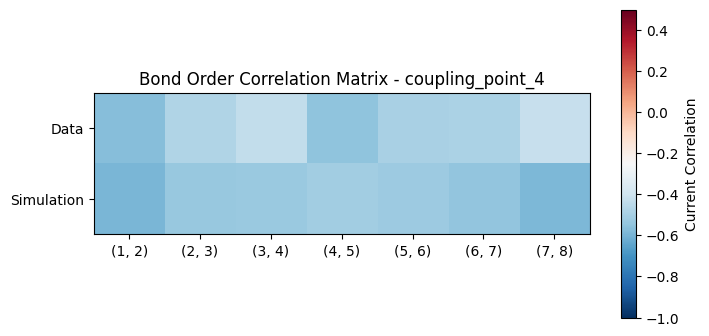

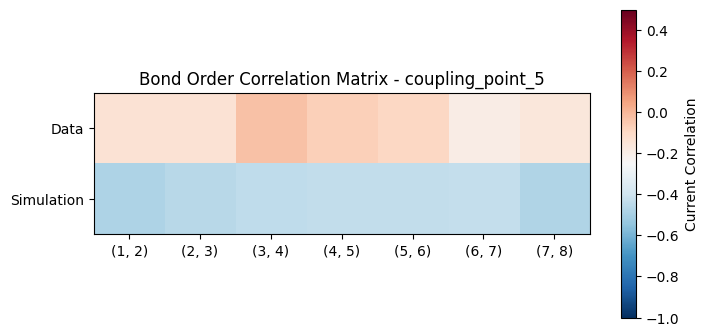

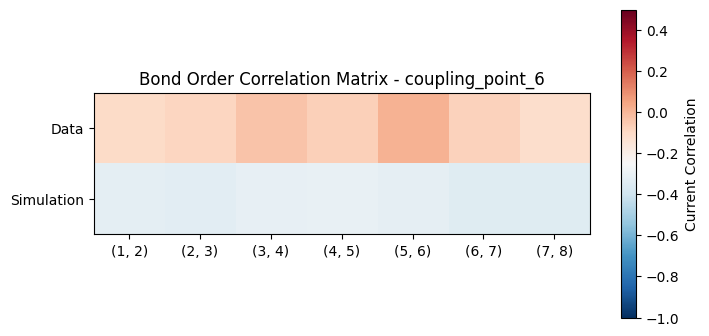

Max bond order value across all coupling points: 0.18381948604785486
Min bond order value across all coupling points: -0.5926087397175462


In [6]:
all_coupling_points = [f'coupling_point_{i}' for i in range(1, 7)]

all_pairs = [(i,i+1) for i in range(1,8)]
print(all_pairs)

dephasing = 'real'

max_value = -np.inf
min_value = np.inf

for coupling_point in all_coupling_points:

    if coupling_point in data['data']:

        coupling_point_data = data['data'][coupling_point][eigenstate]
        coupling_point_sim = data['simulation'][eigenstate_base][dephasing][coupling_point]

        # first row is data, second row is simulation
        bond_order_matrix = np.zeros((2, len(all_pairs)))

        for i in range(len(all_pairs)):

            pair = all_pairs[i]

            bond_order_data = coupling_point_data[str(pair)]['bond_order_value']
            bond_order_sim_BS = coupling_point_sim[str(pair)]['bond_order_value_BS']


            if coupling_point in ['coupling_point_5', 'coupling_point_6']:
                bond_order_matrix[0, i] = bond_order_data
            else:
                bond_order_matrix[0, i] = bond_order_data
            bond_order_matrix[1, i] = bond_order_sim_BS
    else:
        # for coupling points with no data, fill with randoms for now
        bond_order_matrix = (np.random.rand(2, len(all_pairs)) - 0.5)*0.2

    if np.max(bond_order_matrix) > max_value:
        max_value = np.max(bond_order_matrix)
    if np.min(bond_order_matrix) < min_value:
        min_value = np.min(bond_order_matrix)

    fig, ax = plt.subplots(figsize=(8,4))

    vmin = -1
    vmax = 0.5
    im = ax.imshow(bond_order_matrix, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(all_pairs)))
    ax.set_xticklabels(all_pairs)
    ax.set_yticks(np.arange(2))
    ax.set_yticklabels(['Data', 'Simulation'])
    fig.colorbar(im, ax=ax, label='Current Correlation')

    plt.title(f'Bond Order Correlation Matrix - {coupling_point}')

    plt.show()

    # default is highest eigenstate and real dephasing
    correlation_matrix_filename = f'plots\\bond_order_matrices\\{coupling_point}_bond_order_matrix.csv'
    with open(correlation_matrix_filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        for i in range(2):
            row = list(bond_order_matrix[i, :])
            writer.writerow(row)
    
print(f'Max bond order value across all coupling points: {max_value}')
print(f'Min bond order value across all coupling points: {min_value}')

In [7]:
# for coupling_point in all_coupling_points:
#     if coupling_point in data['data']:
#         print()
#         print(f'{coupling_point}')
#         print()
#         # print_tree(data['data'][coupling_point]['highest'], max_level=2)
#         print(data['data'][coupling_point]['highest']['current_correlation_total'])

In [8]:
# all_coupling_points = [f'coupling_point_{i}' for i in range(1, 7)]

# all_pairs = [(i,i+1) for i in range(1,8)]
# print(all_pairs)

# dephasing = 'real'

# for coupling_point in all_coupling_points:

#     if coupling_point in data['data']:

#         coupling_point_data = data['data'][coupling_point]['highest']
#         print(data['data'][coupling_point]['highest']['current_correlation_total'])
#         coupling_point_sim = data['simulation']['highest'][dephasing][coupling_point]

#         print(coupling_point)
#         print(coupling_point_data.keys())

#         distance_to_current_correlation_error = coupling_point_data['distance_to_current_correlation_error']
#         distance_to_current_correlation_value = coupling_point_data['distance_to_current_correlation_value']
        
#         current_correlation_averages = coupling_point_data['current_correlation_averages']
    


In [9]:
### export total bond order explicitly

values = []
errors = []
for coupling_point in all_coupling_points:
    if coupling_point in data['data']:
        coupling_point_data = data['data'][coupling_point][eigenstate]
        value = coupling_point_data['bond_order_total']
        if 'bond_order_total_error' in coupling_point_data:
            error = coupling_point_data['bond_order_total_error_corrected']
        else:
            error = 50
    else:
        value = 0
        error = 50
    values.append(value)
    errors.append(error)

print(values)
print(errors)

with open('plots/bond_order_totals.csv', 'w', newline='\n') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(values)
    writer.writerow(errors)

[np.float64(1.4778188422629952), np.float64(0.4862094816083515), np.float64(0.31718219090897465), np.float64(0.40845450858379834), np.float64(0.03393560560515055), np.float64(0.014831683975035412)]
[np.float64(0.006466053617497465), np.float64(0.0024518891980772825), np.float64(0.0035585041532275236), np.float64(0.005706288213802726), np.float64(0.00836895525256504), np.float64(0.005011862968624927)]
